## Elaborado por: Alexis Gael Hilario Velázquez

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bibfunciones as bf
import scipy.constants as cte

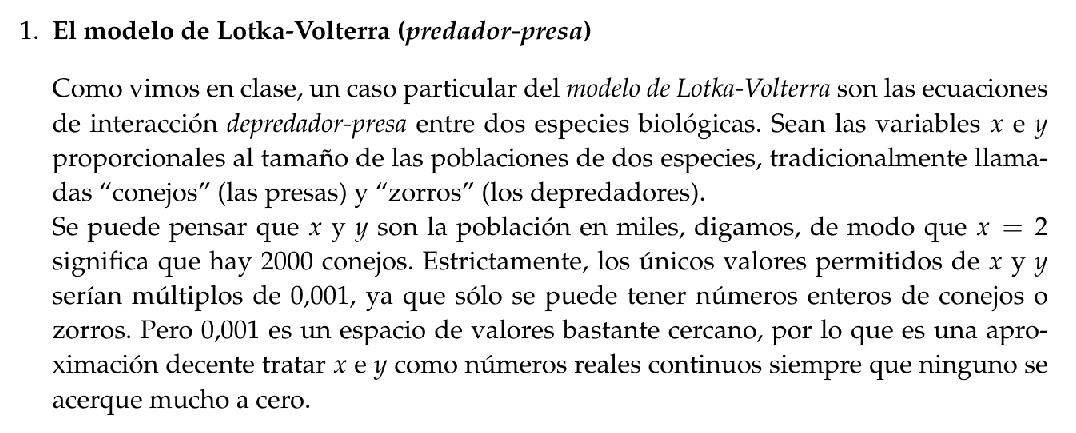 \ 
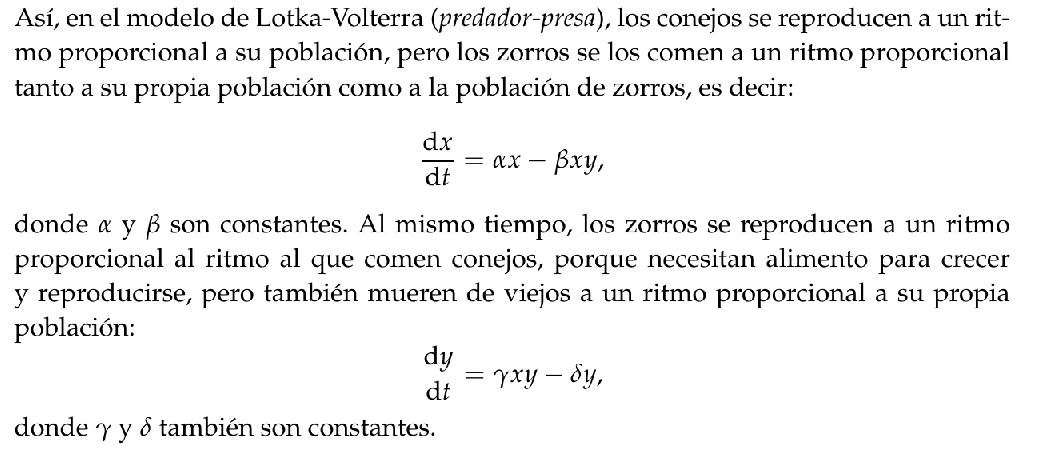 \ 
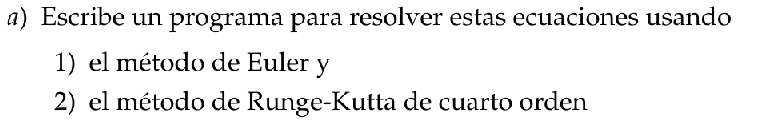 \ 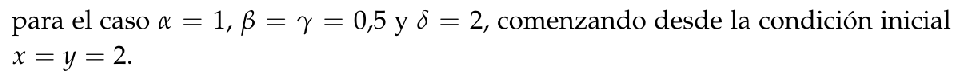

In [2]:
def p_punto(z,a,b,gamma,delta):
    return np.array([a*z[0]-b*z[0]*z[1], gamma*z[0]*z[1]-delta*z[1]])

In [3]:
p0 = np.array([2,2])
zorros = [p0[0]]
conejos = [p0[1]]
dt = 0.01
t = 0
tf = 30
T = [t]
a = 1.0
b = g = 0.5
d = 2
while (t<tf):
    p0 = p0 + p_punto(p0,a,b,g,d)*dt
    t = t + dt
    zorros.append(p0[0])
    conejos.append(p0[1])
    T.append(t)


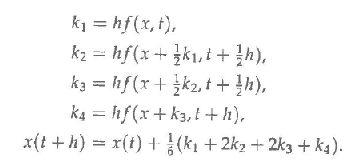


In [4]:
#Runge_kutta_4orden 
p0 = np.array([2,2])
zorrosRK = [p0[0]]
conejosRK = [p0[1]]
TRK = [t]
dt = 0.01
t = 0
tf = 30
a = 1.0
b = g = 0.5
d = 2
while (t<tf):
    k1 = dt*p_punto(p0,a,b,g,d)
    k2 = dt*p_punto(p0 + k1/2, a,b,g,d)
    k3 = dt*p_punto(p0 + k2/2, a,b,g,d)
    k4 = dt*p_punto(p0 + k3,a,b,g,d)
    p0 = p0 + (k1+2*k2+2*k3+k4)/6
    t = t + dt
    zorrosRK.append(p0[0])
    conejosRK.append(p0[1])
    TRK.append(t)

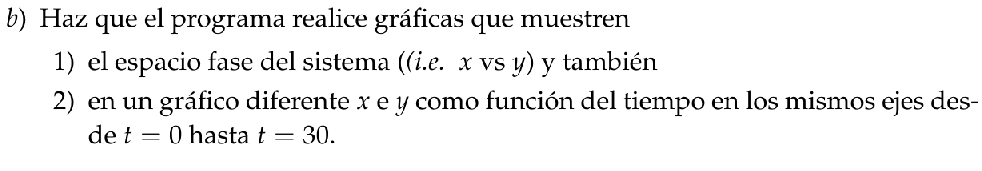

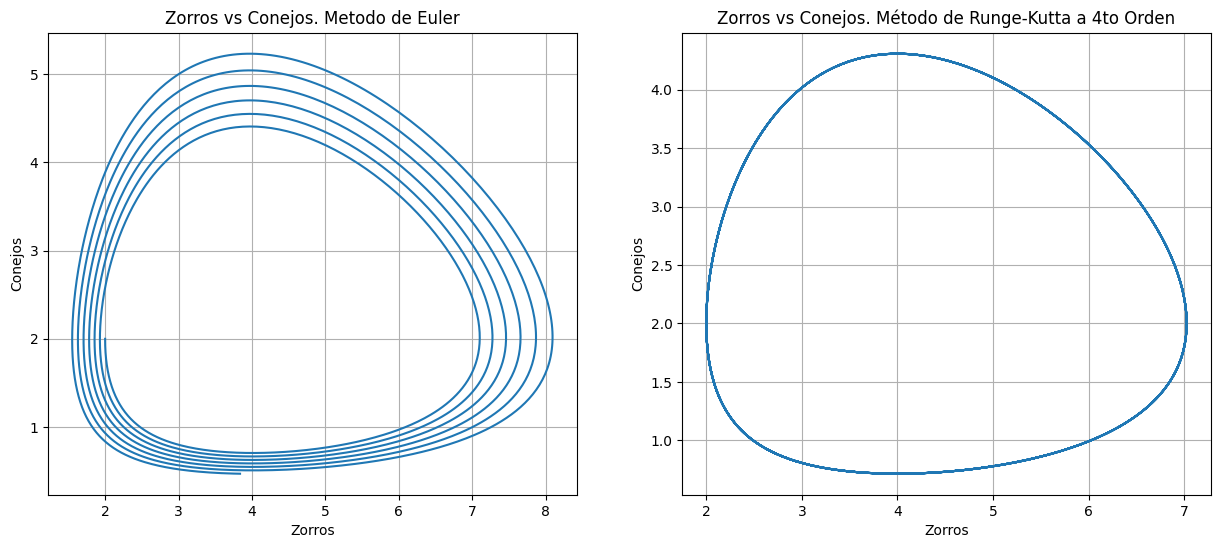

In [5]:
plt.figure(figsize = [15,6])
plt.subplot(1,2,1)
plt.title('Zorros vs Conejos. Metodo de Euler')
plt.plot(zorros,conejos)
plt.xlabel('Zorros')
plt.ylabel('Conejos')
plt.grid()

plt.subplot(1,2,2)
plt.title('Zorros vs Conejos. Método de Runge-Kutta a 4to Orden')
plt.plot(zorrosRK,conejosRK)
plt.xlabel('Zorros')
plt.ylabel('Conejos')
plt.grid()

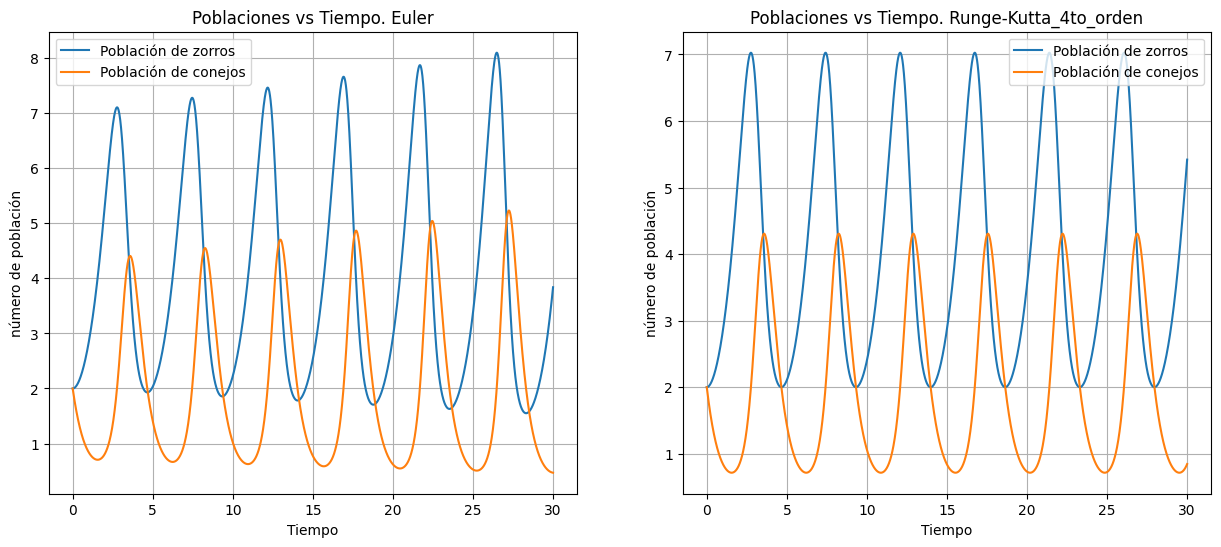

In [6]:
plt.figure(figsize = [15,6])
plt.subplot(1,2,1)
plt.title('Poblaciones vs Tiempo. Euler')
plt.plot(T, zorros, label = 'Población de zorros')
plt.plot(T, conejos, label = 'Población de conejos')
plt.ylabel('número de población')
plt.xlabel('Tiempo')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.title('Poblaciones vs Tiempo. Runge-Kutta_4to_orden')
plt.plot(T, zorrosRK, label = 'Población de zorros')
plt.plot(T, conejosRK, label = 'Población de conejos')
plt.ylabel('número de población')
plt.xlabel('Tiempo')
plt.legend()
plt.grid()

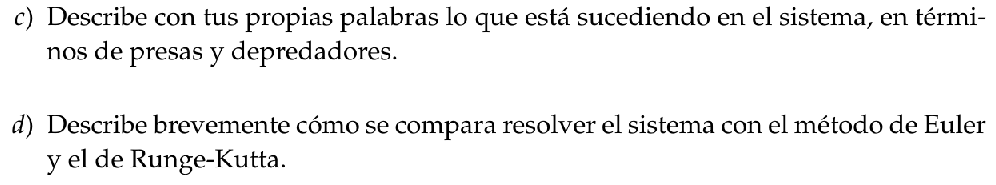

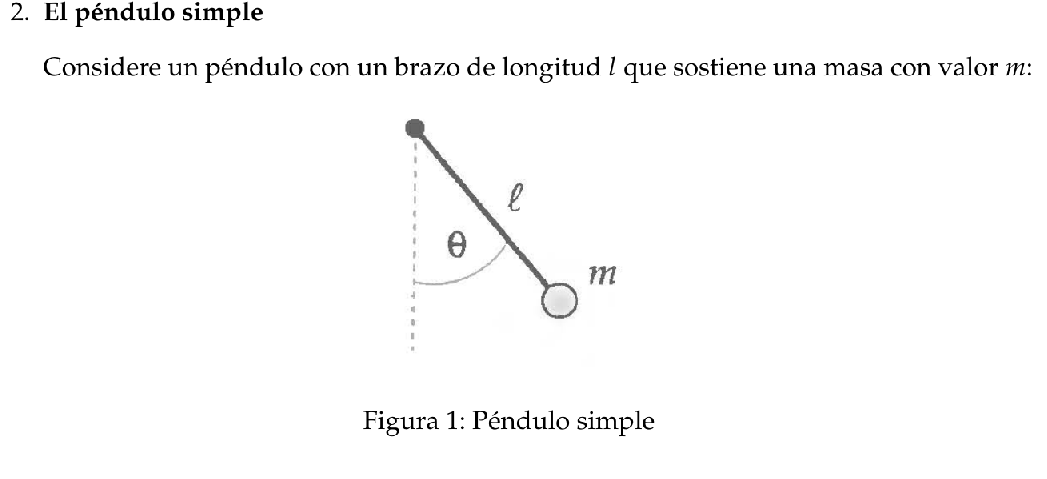
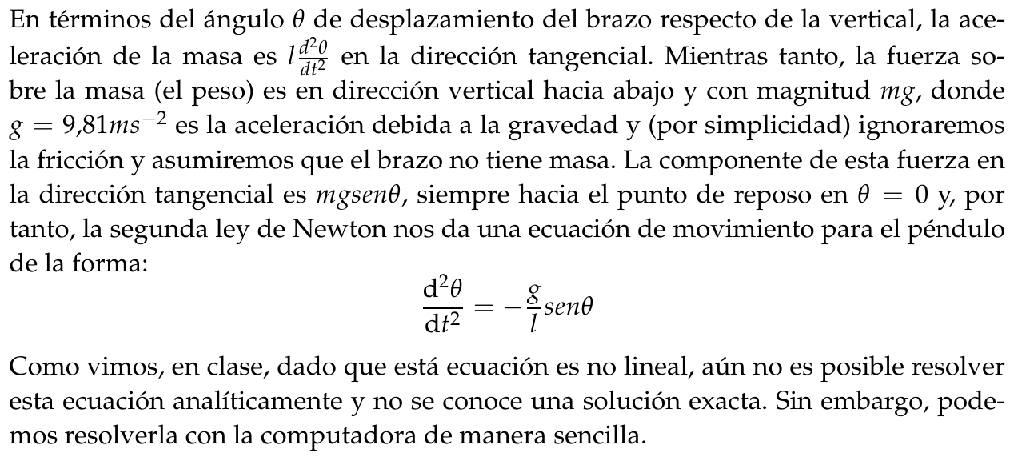
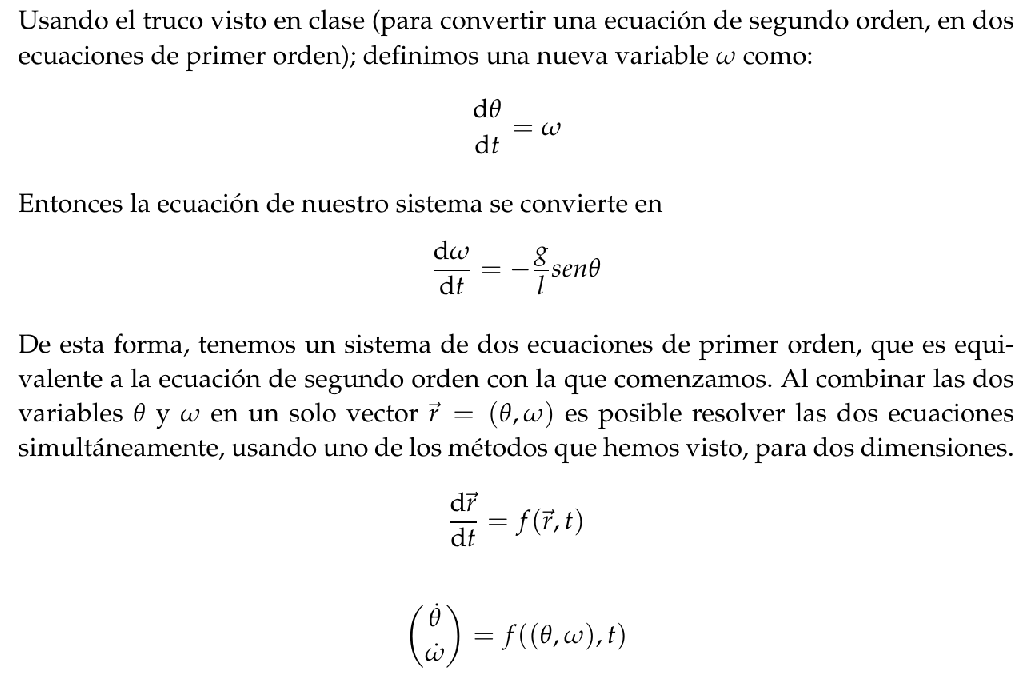

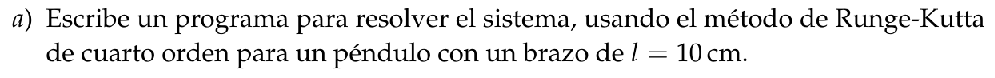

In [7]:
def TyO_punto(z,l):
    d_theta = z[1]
    d_omega = -(9.81/l)*np.sin(z[0])
    return np.array([d_theta,d_omega])

In [8]:
#Runge_kutta_4orden 
def Pendulo_simple(theta,l):
    p0 = np.array([theta,0])
    X = [p0[0]]
    Y = [p0[1]]
    t = 0
    T1 = [t]
    dt = 0.01
    tf = 30
    a = 1.0
    b = g = 0.5
    d = 2
    while (t<=tf):
        k1 = dt*TyO_punto(p0,l)
        k2 = dt*TyO_punto(p0+k1/2,l)
        k3 = dt*TyO_punto(p0+k2/2,l)
        k4 = dt*TyO_punto(p0+k3,l)
        p0 = p0 + (k1+2*k2+2*k3+k4)/6
        t = t + dt
        X.append(p0[0])
        Y.append(p0[1])
        T1.append(t)
    return X, Y, T1

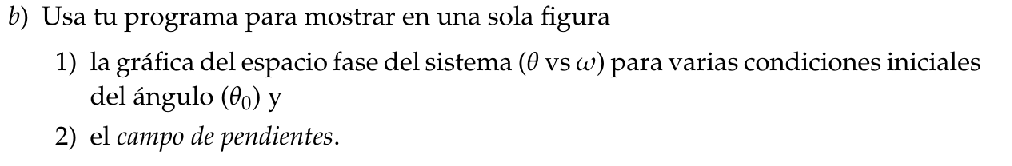

In [9]:
Xs = []
Ys = []
theta_iniciales = np.linspace(-np.pi,np.pi,20)
for theta0 in theta_iniciales:
    X0 = Pendulo_simple(theta0,0.1)[0]
    Y0 = Pendulo_simple(theta0,0.1)[1]
    Xs.append(X0)
    Ys.append(Y0)
T = Pendulo_simple(0,0.1)[2]

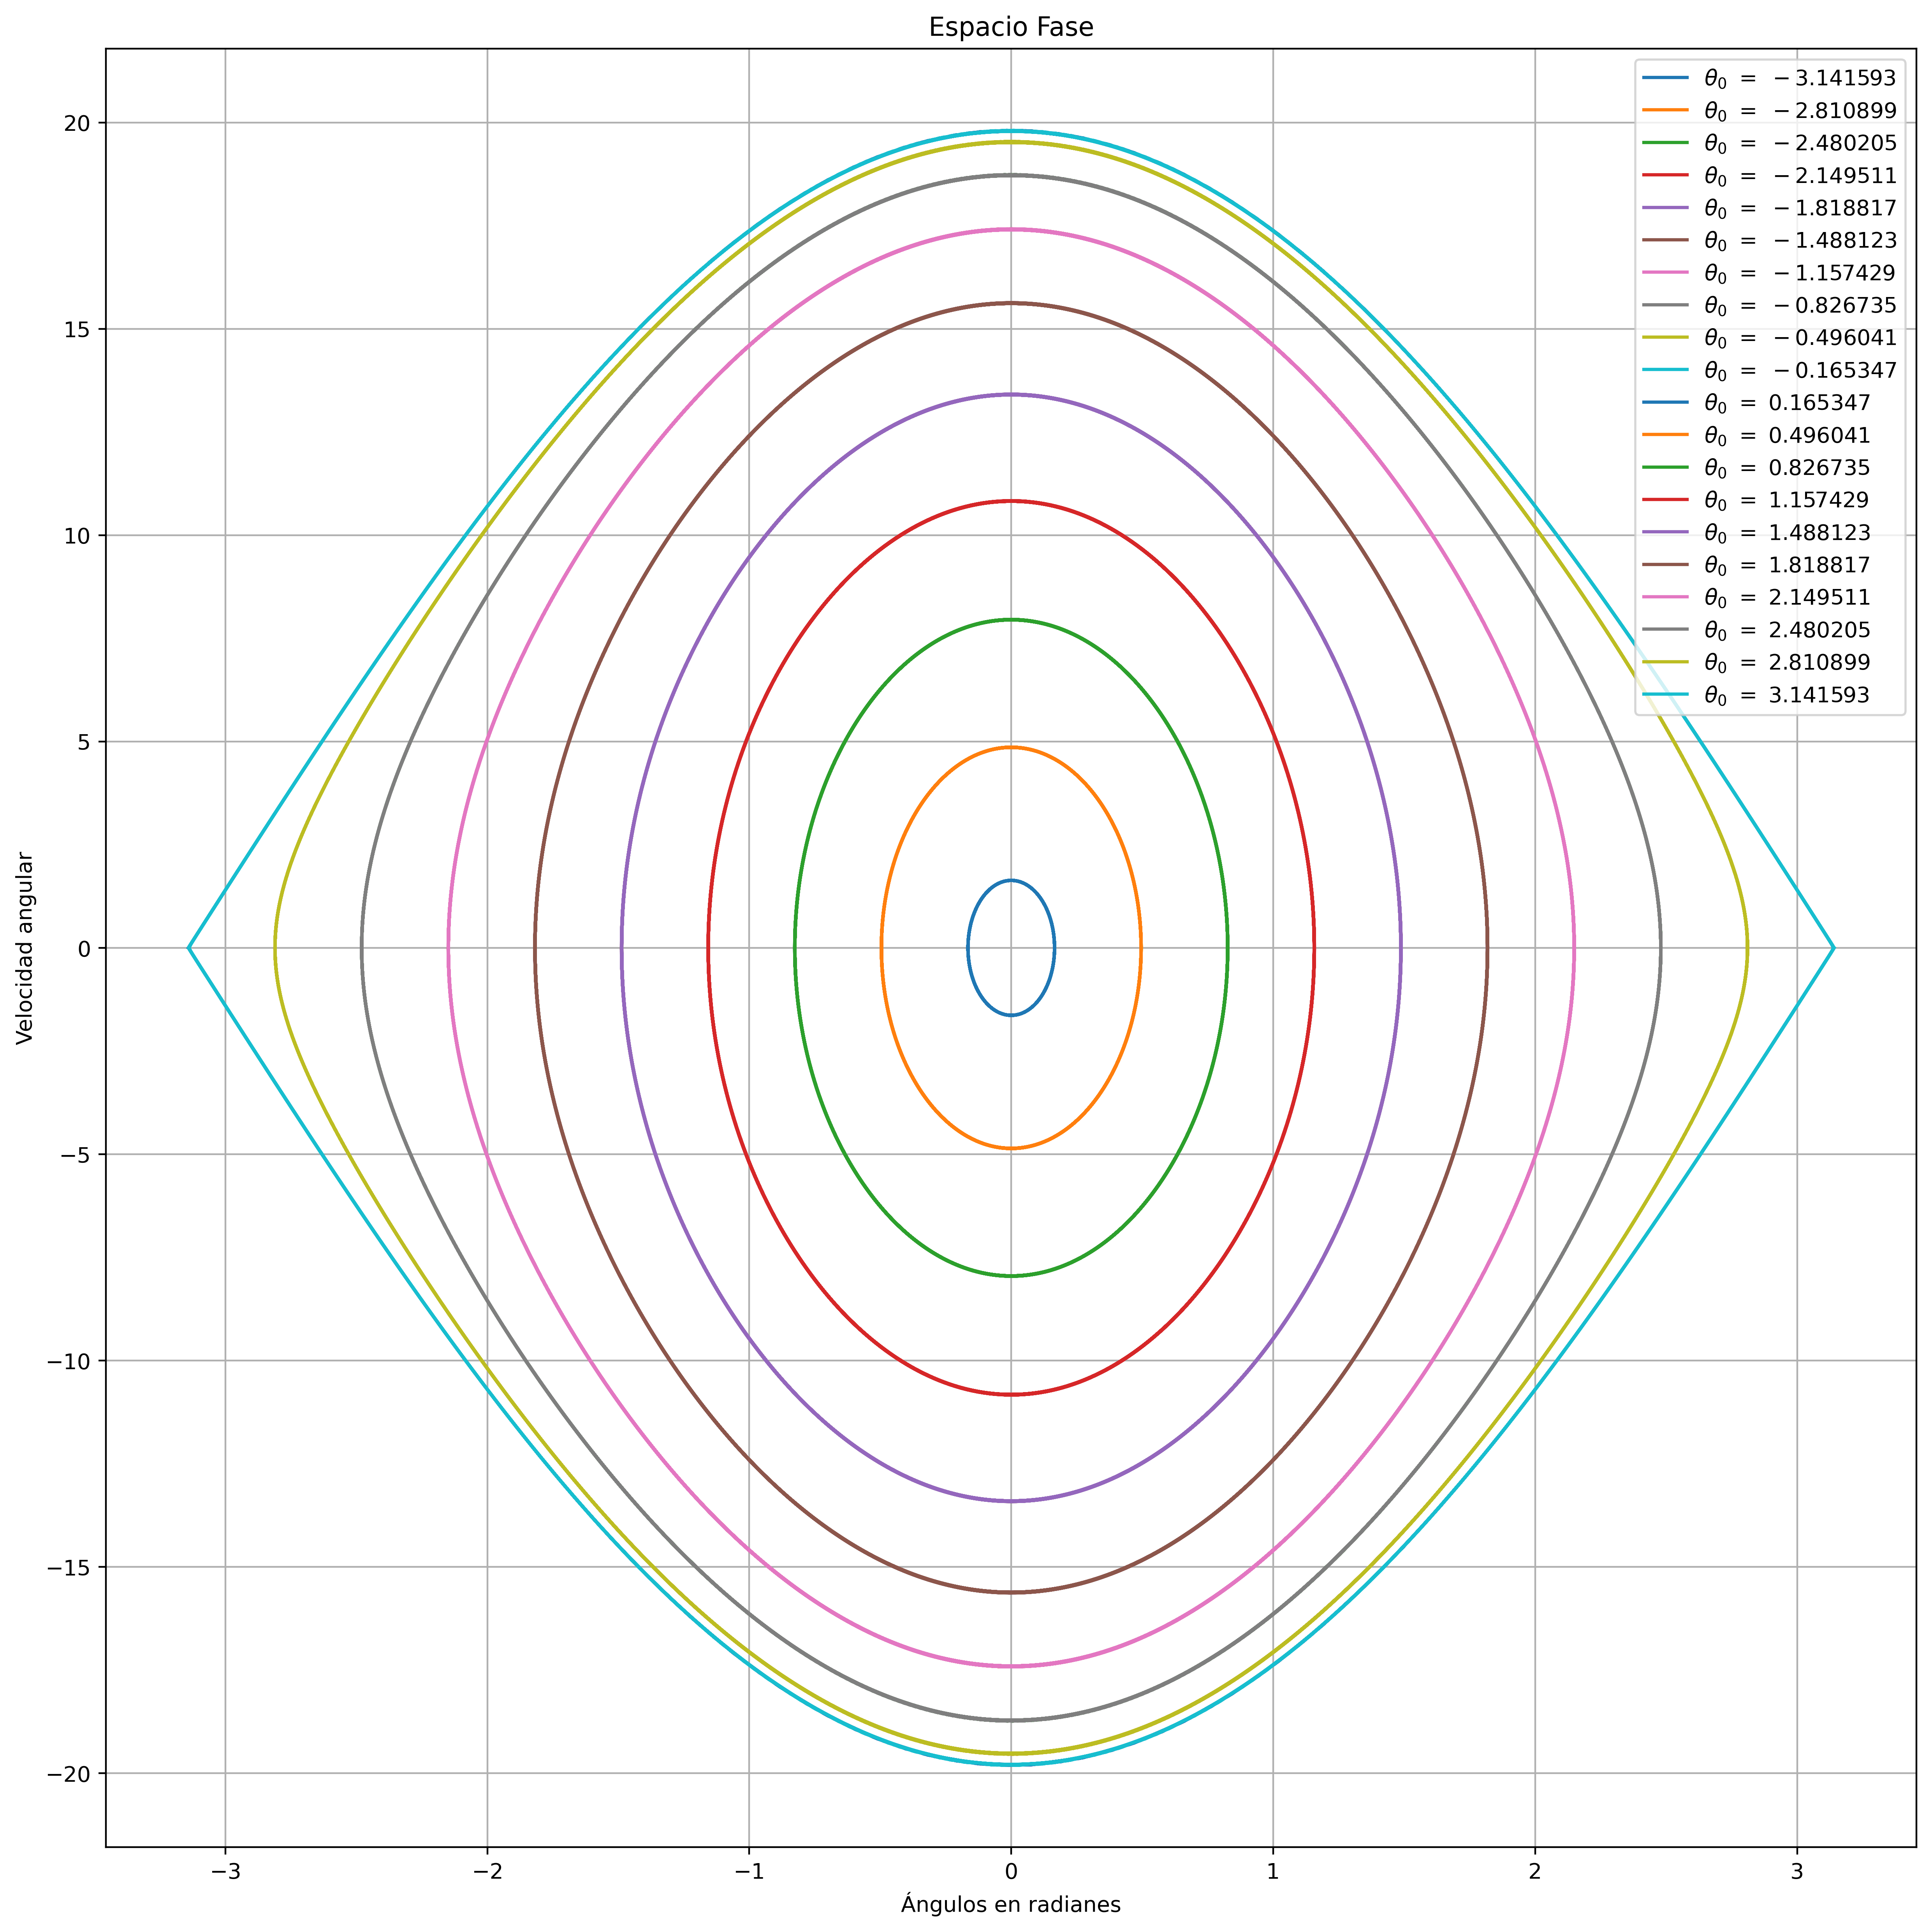

In [10]:
fig, ax = plt.subplots(figsize = (15,15), dpi = 400)
for i in range(len(Xs)):
    ax.plot(Xs[i], Ys[i] , label=r'$\theta_0 \ = \ %f$'%theta_iniciales[i])
plt.title('Espacio Fase')
plt.xlabel('Ángulos en radianes')
plt.ylabel('Velocidad angular')
ax.legend()
ax.grid()
#plt.savefig('Pendulo_simple.png', dpi = 400)

In [11]:
### Campos de pendientes 
def dwdthetha(theta,w):
    g = 9.81
    l = 0.1
    return -g*np.sin(theta)/(l*w)

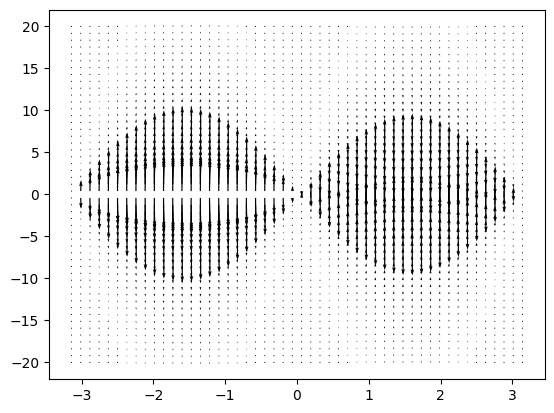

In [12]:
theta_iniciales = np.linspace(-np.pi,np.pi,50)
Y = np.linspace(-20,20,50)
x, y = np.meshgrid(theta_iniciales,Y)
dtheta = y
d_omega = -(9.81/0.1)*np.sin(x)/y

plt.quiver(x,y,1,d_omega)


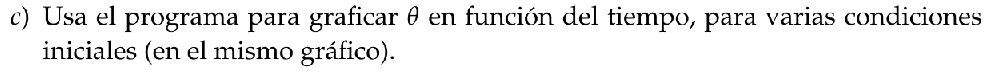

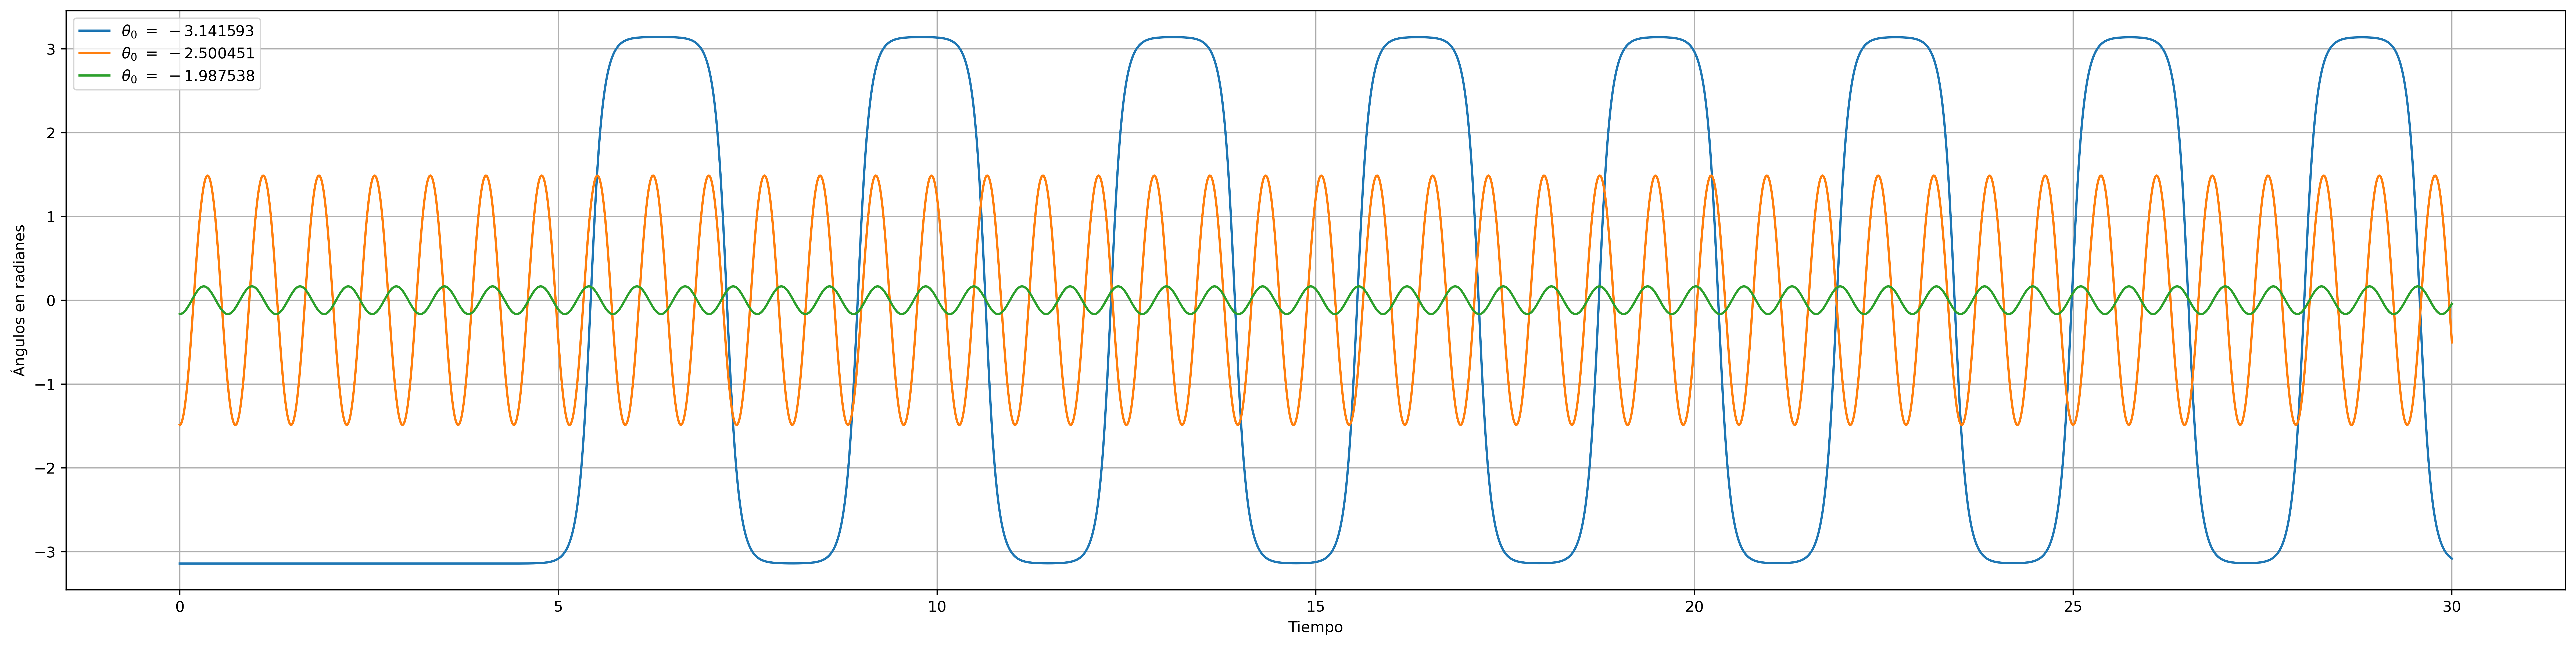

In [13]:
fig, ax = plt.subplots(figsize = (30,7), dpi = 400)

ax.plot(T, Xs[0]  ,label=r'$\theta_0 \ = \ %f$'%theta_iniciales[0])
ax.plot(T, Xs[5]  ,label=r'$\theta_0 \ = \ %f$'%theta_iniciales[5])
ax.plot(T, Xs[9]  ,label=r'$\theta_0 \ = \ %f$'%theta_iniciales[9])
plt.xlabel('Tiempo')

plt.ylabel('Ángulos en radianes')
ax.legend()
ax.grid()

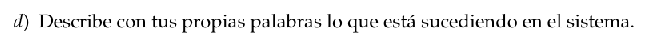

Puedo observar que a mayores angulos es mayor la velocidad angular que alcanza y en los gráficas de $ \theta_0 $ vs tiempo vemos que mayor angulo realiza menores oscilaciones, mientras que a hacia angulos pequeños realiza mayores oscilaciones en un tiempo menor. 
Todo este analisis se realizo para velocidad angular inicial igual a cero.

## 3. Pendulo Doble

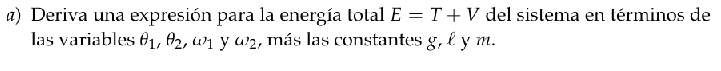

De las siguientes imagenes obtenemos expresiones para T y V. \
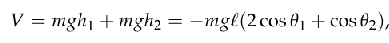 \
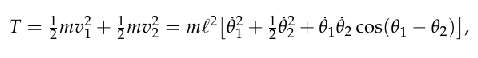\
Por lo tanto, la energía queda de la siguiente manera:

In [14]:
#### Energía
def Energia(z1,z2,z1_p,z2_p, m, l):
    g = 9.81
    E = m*l**2*(z1_p**2+z2_p**2/2+z1_p*z2_p*np.cos(z1-z2))-m*g*l*(2*np.cos(z1)+np.cos(z2))
    return E

Para resolver el inciso b). \
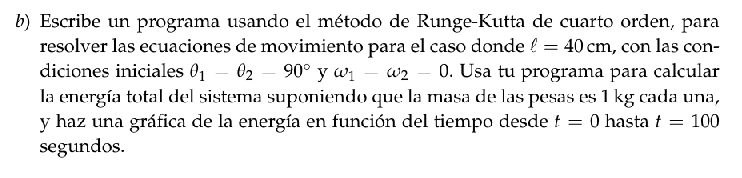 \
Ahora resolvemos las ecuaciones de movimiento. \
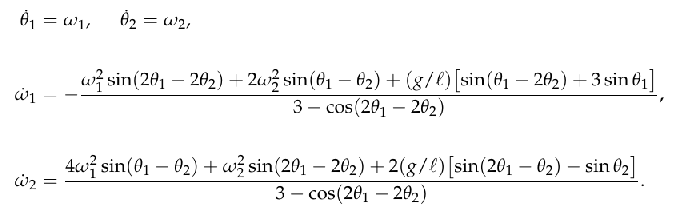

In [15]:
def PO_punto(z,l): #La derivada en 4D se expresa entrada a entra con las ecuaciones de movimiento
    g = 9.81
    d_theta_1 = z[2]
    d_theta_2 = z[3]
    d_omega_1 = -(z[2]**2*np.sin(2*z[0]-2*z[1])+2*z[3]**2*np.sin(z[0]-z[1])+(g/l)*np.sin(z[0]-2*z[1])+3*np.sin(z[0]))/(3-np.cos(2*z[0]-2*z[1]))
    d_omega_2 = (4*z[2]**2*np.sin(2*z[0]-2*z[1])+z[3]**2*np.sin(2*(z[0]-z[1]))+2*(g/l)*np.sin(2*z[0]-z[1])+np.sin(z[1]))/(3-np.cos(2*z[0]-2*z[1]))
    return np.array([d_theta_1,d_theta_2,d_omega_1, d_omega_2])

In [16]:
#Runge_kutta_4orden 
def Pendulo_doble(theta1,theta2,omega1,omega2,l,tf):
    p0 = np.array([theta1,theta2,omega1,omega2])
    X1 = [p0[0]]
    X2 = [p0[1]]
    Y1 = [p0[2]]
    Y2 = [p0[3]]
    t = 0
    T1 = [t]
    dt = 1e-4
    while (t<=tf):
        k1 = dt*PO_punto(p0,l)
        k2 = dt*PO_punto(p0+k1/2,l)
        k3 = dt*PO_punto(p0+k2/2,l)
        k4 = dt*PO_punto(p0+k3,l)
        p0 = p0 + (k1+2*k2+2*k3+k4)/6
        t = t + dt
        X1.append(p0[0])
        X2.append(p0[1])
        Y1.append(p0[2])
        Y2.append(p0[3])
        T1.append(t)
    return X1, X2 ,Y1, Y2, T1

In [17]:
EC_mov = Pendulo_doble(np.pi/2,np.pi/2,0,0,0.4,100)

In [18]:
EC_mov = np.array(EC_mov)
Energy = Energia(EC_mov[0], EC_mov[1], EC_mov[2], EC_mov[3], 1, 0.4)

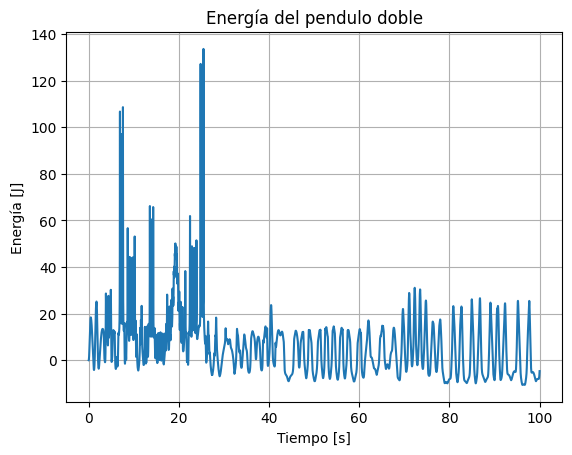

In [19]:
plt.title('Energía del pendulo doble')
plt.plot(EC_mov[4], Energy)
plt.xlabel('Tiempo [s]')
plt.ylabel('Energía [J]')
plt.grid()

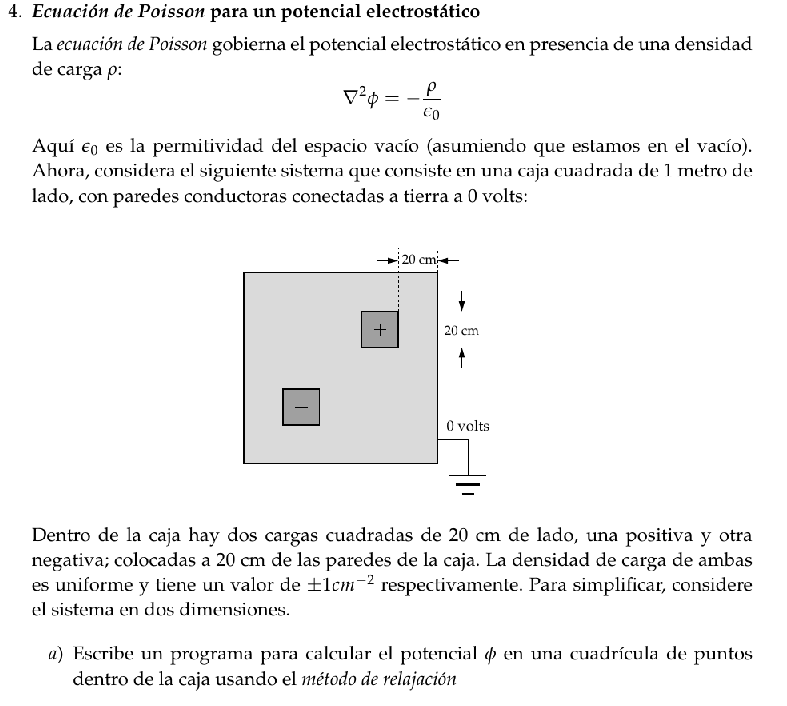

In [20]:
def densidad_carga(x,y):
    epsilon_0 = 1
    if (20 <= x <= 40 and 20 <= y <= 40):
        f = 10000/epsilon_0 #convirtiendo cm{-2} a m{-2}
    elif (60 <= x <= 80 and 60 <= y <= 80):
        f = -10000/epsilon_0
    else:
        f = 0
    return f

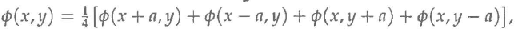

In [21]:
### relajación
### Realizamos un meshgrid de la siguiente manera
N = 91
malla_x = np.linspace(0,100,N)
malla_y = np.linspace(100,0,N)
x1 , y1 = np.meshgrid(malla_x, malla_y)
error = 1
min_err= 1e-6
Malla = np.zeros([N,N],float)

while error > min_err: #creamos un while para que obtengamos precisión
    M = np.copy(Malla) #copiamos los valores de la malla
    for i in range(N):
        for j in range(N): #aplicamos ciclos for para cada punto
            if (i == 0 or i == N-1 or j == 0 or j == N-1): #si nos ubicamos en el borde
                Malla[i,j] = Malla[i,j] #se queda igual el valor
            else: #si estamos en otra parte que no lo sea
                Malla[i,j] = (Malla[i+1,j] + Malla[i-1,j] + Malla[i,j+1] + Malla[i,j-1]+ densidad_carga(x1[i,j],y1[i,j]))/4 #aplicamos la densidad de carga adicional
            
    error = np.max(np.abs(Malla-M)) #el error sera la maxima diferencia de alguno de los valores de la malla 


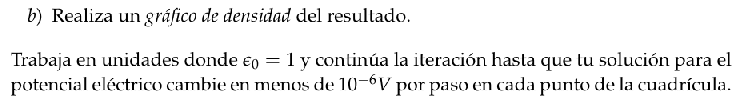

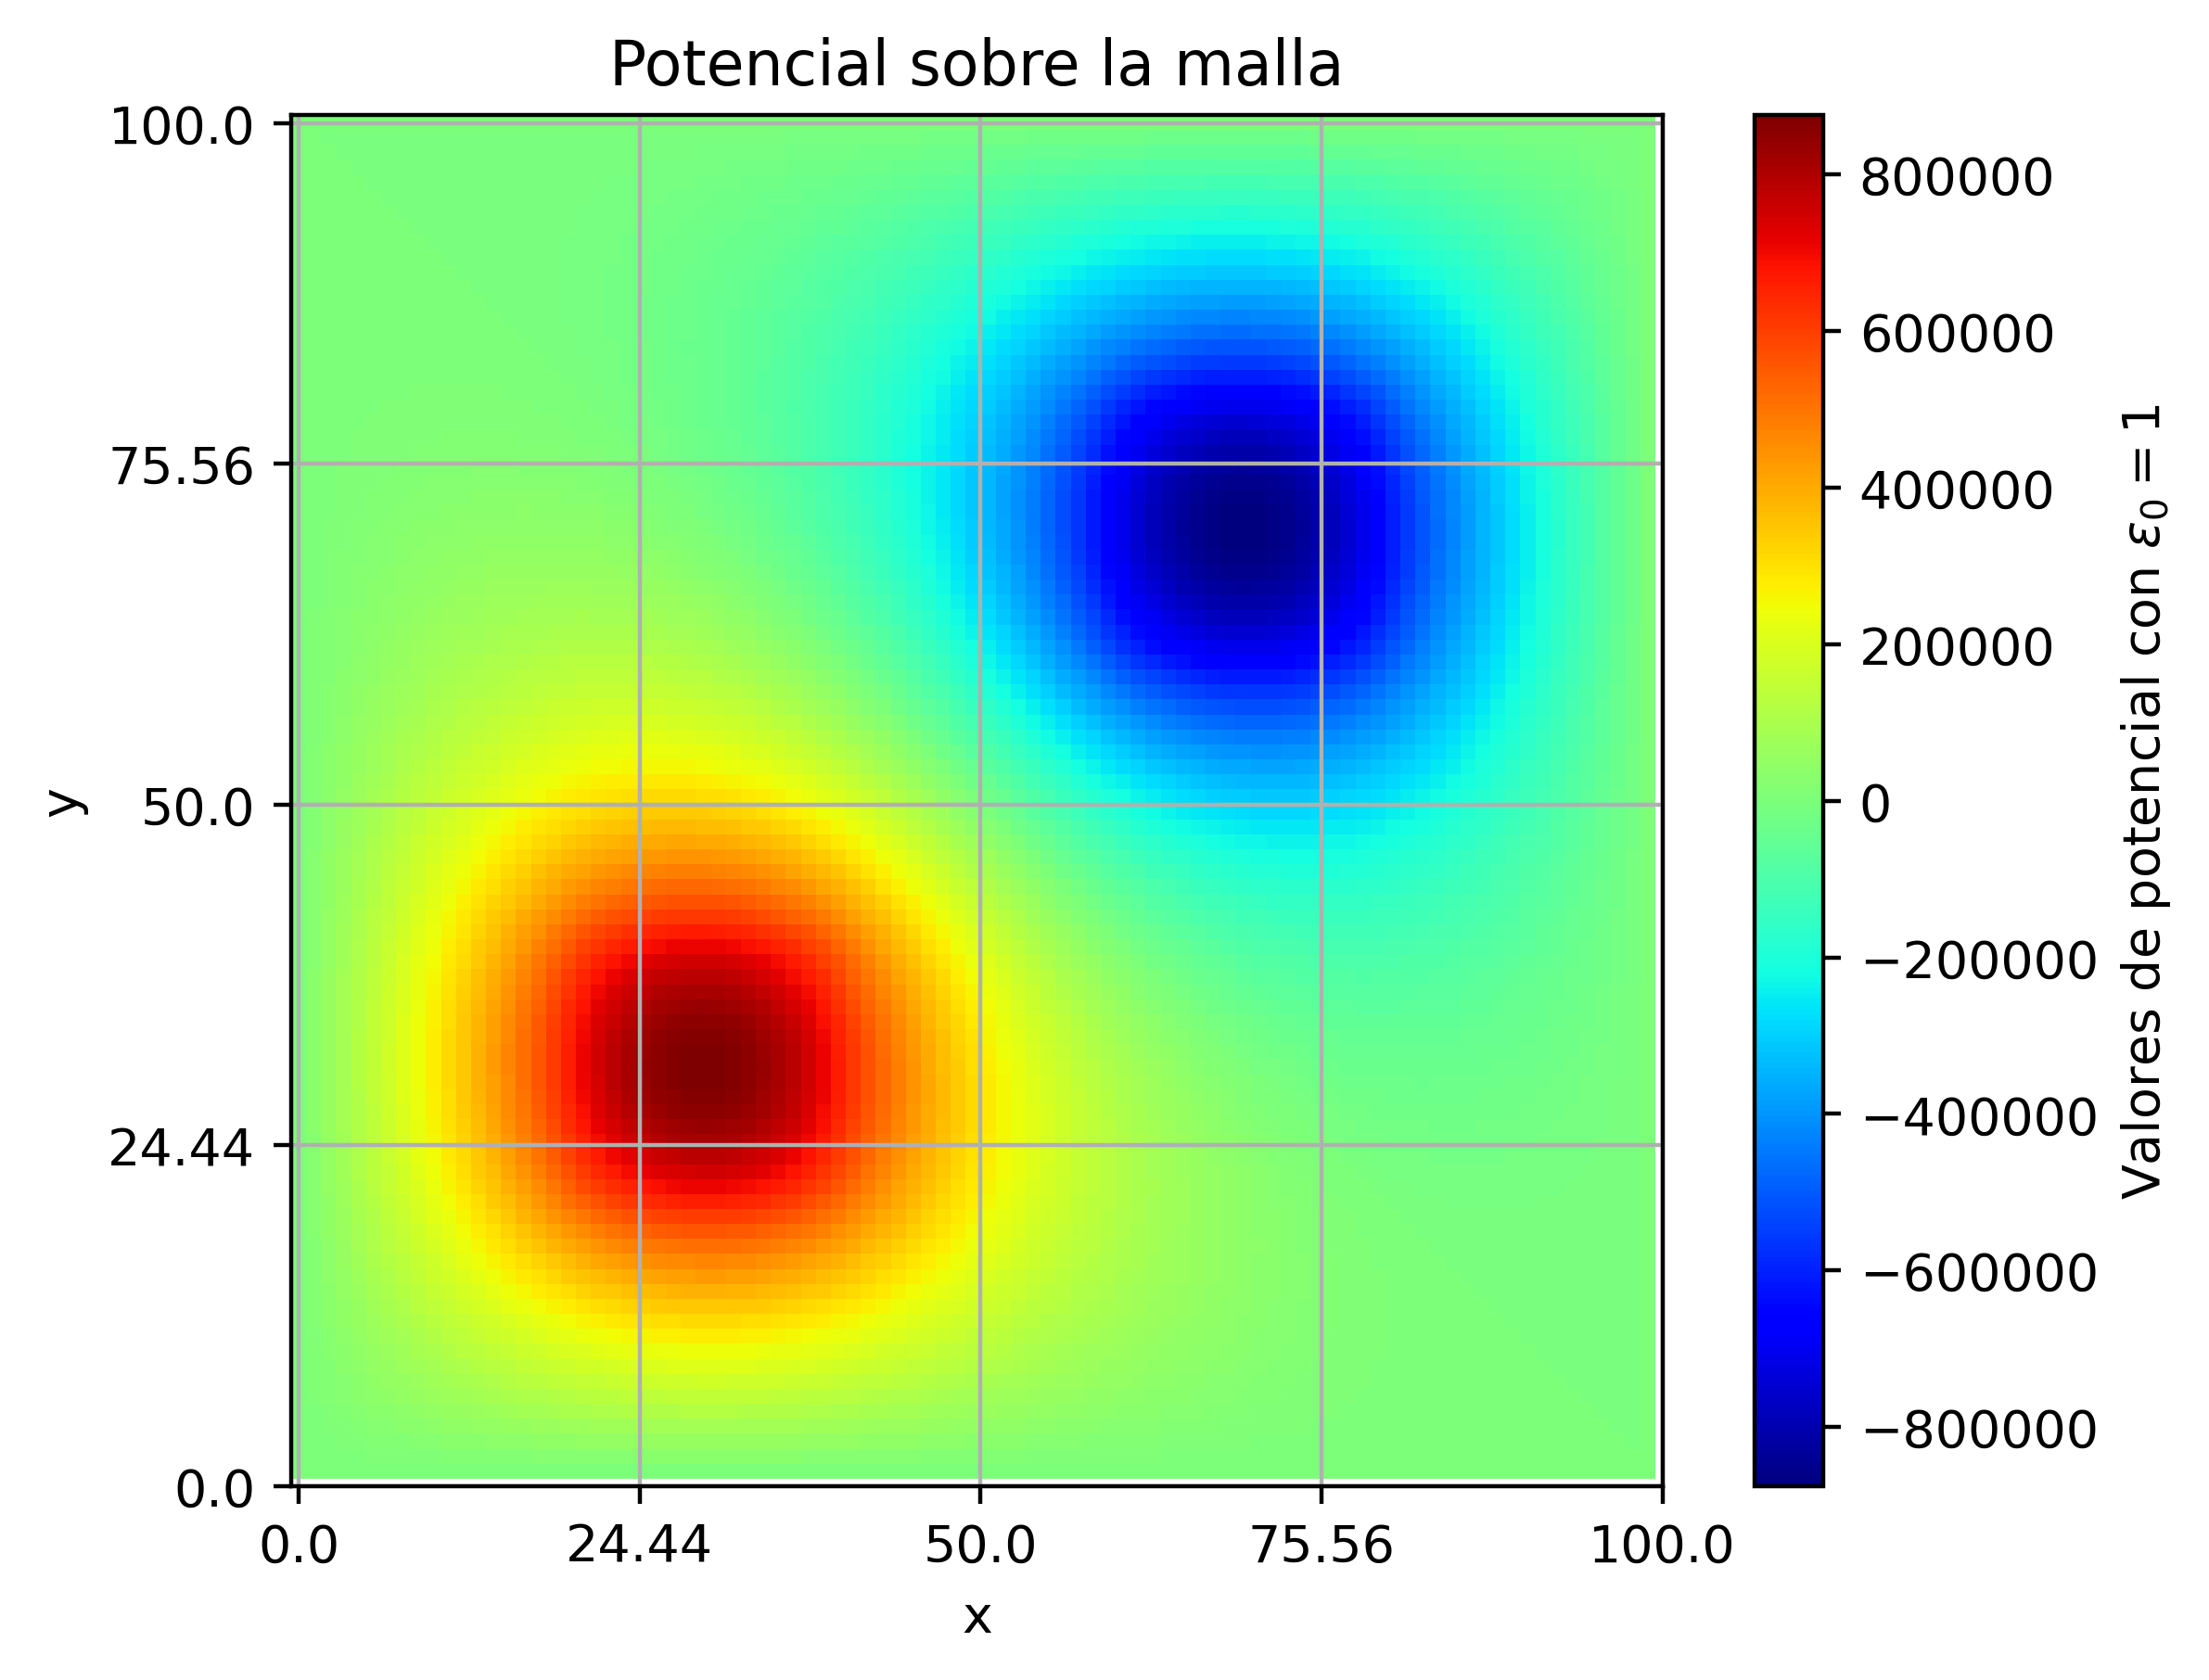

In [22]:
plt.figure(dpi = 400) #creamos una figura que nos imprima un imshow para observar el potencial
Imagen = plt.imshow(Malla, cmap = 'jet')
plt.title("Potencial sobre la malla")
plt.xticks([0, N/4, N/2, 3*N/4, N], [malla_x[0], np.round(malla_x[int(np.round((N-1)/4))],2), np.round(malla_x[int(np.round((N-1)/2))],2), np.round(malla_x[int(np.round(3*(N-1)/4))],2) ,np.round(malla_x[N-1],2)])
plt.yticks([0, N/4, N/2, 3*N/4, N], [malla_y[0], np.round(malla_y[int(np.round((N-1)/4))],2), np.round(malla_y[int(np.round((N-1)/2))],2), np.round(malla_y[int(np.round(3*(N-1)/4))],2) ,np.round(malla_y[N-1],2)])
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
cbar = plt.colorbar(Imagen)
cbar.set_label("Valores de potencial con" + r" $\epsilon_0 = 1 $")

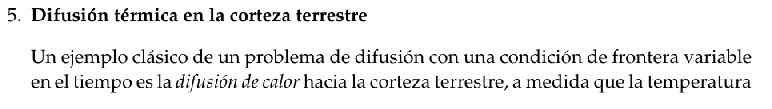 \
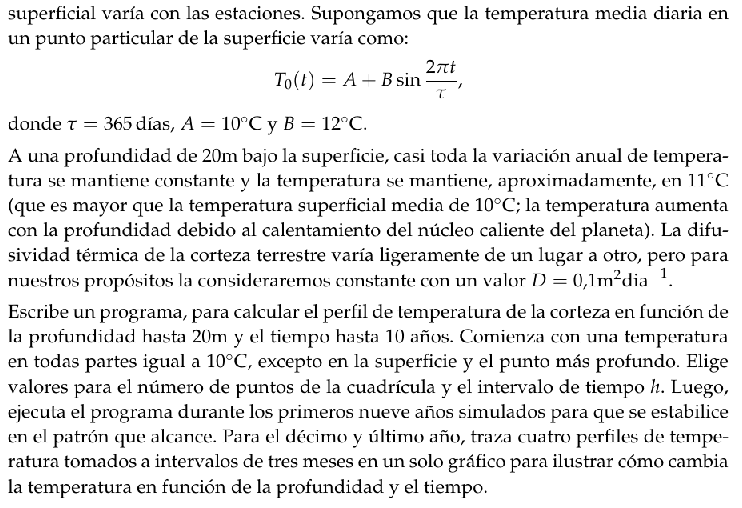

In [32]:
### Realizaremos una cuadricula que a lo ancho sea posición
Ny = 50
profundo = np.linspace(0,20,Ny)
### y a lo largo sea el tiempo 
tiempo = np.arange(0,3650,1)
### ahora un meshgrid de tiempo y profundidad
x, y = np.meshgrid(tiempo, profundo)

In [33]:
### Para dar a la superficie inicial definimos la función
def T0(t):
    T0 = 10-12*np.sin(2*np.pi*t/365)
    return T0

In [34]:
### Creamos un arreglo de la siguiente manera
Corteza = np.zeros(np.shape(x),float) #creamos una nueva matriz donde guardaremos los valores de temperatura de la corteza del tamaño de x que es del mismo tamaño que y
Corteza[0] = T0(tiempo) #utilizamos la función de la temperatura media de la superficie para las condiciones iniciales
Corteza[1:Ny] = 10 #todos los demas 10 excepto el último
Corteza[Ny-1] = 11 #y tomando la información que casi en todas partes a 20 m de profundidad es 11

In [35]:
Corteza

array([[10.        ,  9.79343973,  9.58694066, ..., 10.61943601,
        10.41305934, 10.20656027],
       [10.        , 10.        , 10.        , ..., 10.        ,
        10.        , 10.        ],
       [10.        , 10.        , 10.        , ..., 10.        ,
        10.        , 10.        ],
       ...,
       [10.        , 10.        , 10.        , ..., 10.        ,
        10.        , 10.        ],
       [10.        , 10.        , 10.        , ..., 10.        ,
        10.        , 10.        ],
       [11.        , 11.        , 11.        , ..., 11.        ,
        11.        , 11.        ]], shape=(50, 3650))

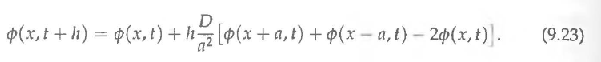

In [36]:
### Utilizando la expresión de arriba con las siguientes constantes
D = 0.1 
a = profundo[1]-profundo[0]
h = 1 #el avance en el tiempo es un dia a la vez (como todo en la vida)
for i in range(Ny): #Ny es el numero de división de la corteza
    for j in range(3649): #en los números de dias
        if i == 0 or i == Ny-1: # si son la superficie o en los 20 metros de profundidad 
            Corteza[i] = Corteza[i] # se mantiene igual la corteza
        else: #si no
            Corteza[i,j+1] = Corteza[i,j] + D*(Corteza[i+1,j]+Corteza[i-1,j]-2*Corteza[i,j])/(a**2) #calculamos el valor del siguiente día dado las condiciones anteriores 
    #error = np.max(np.abs(Corteza-M))


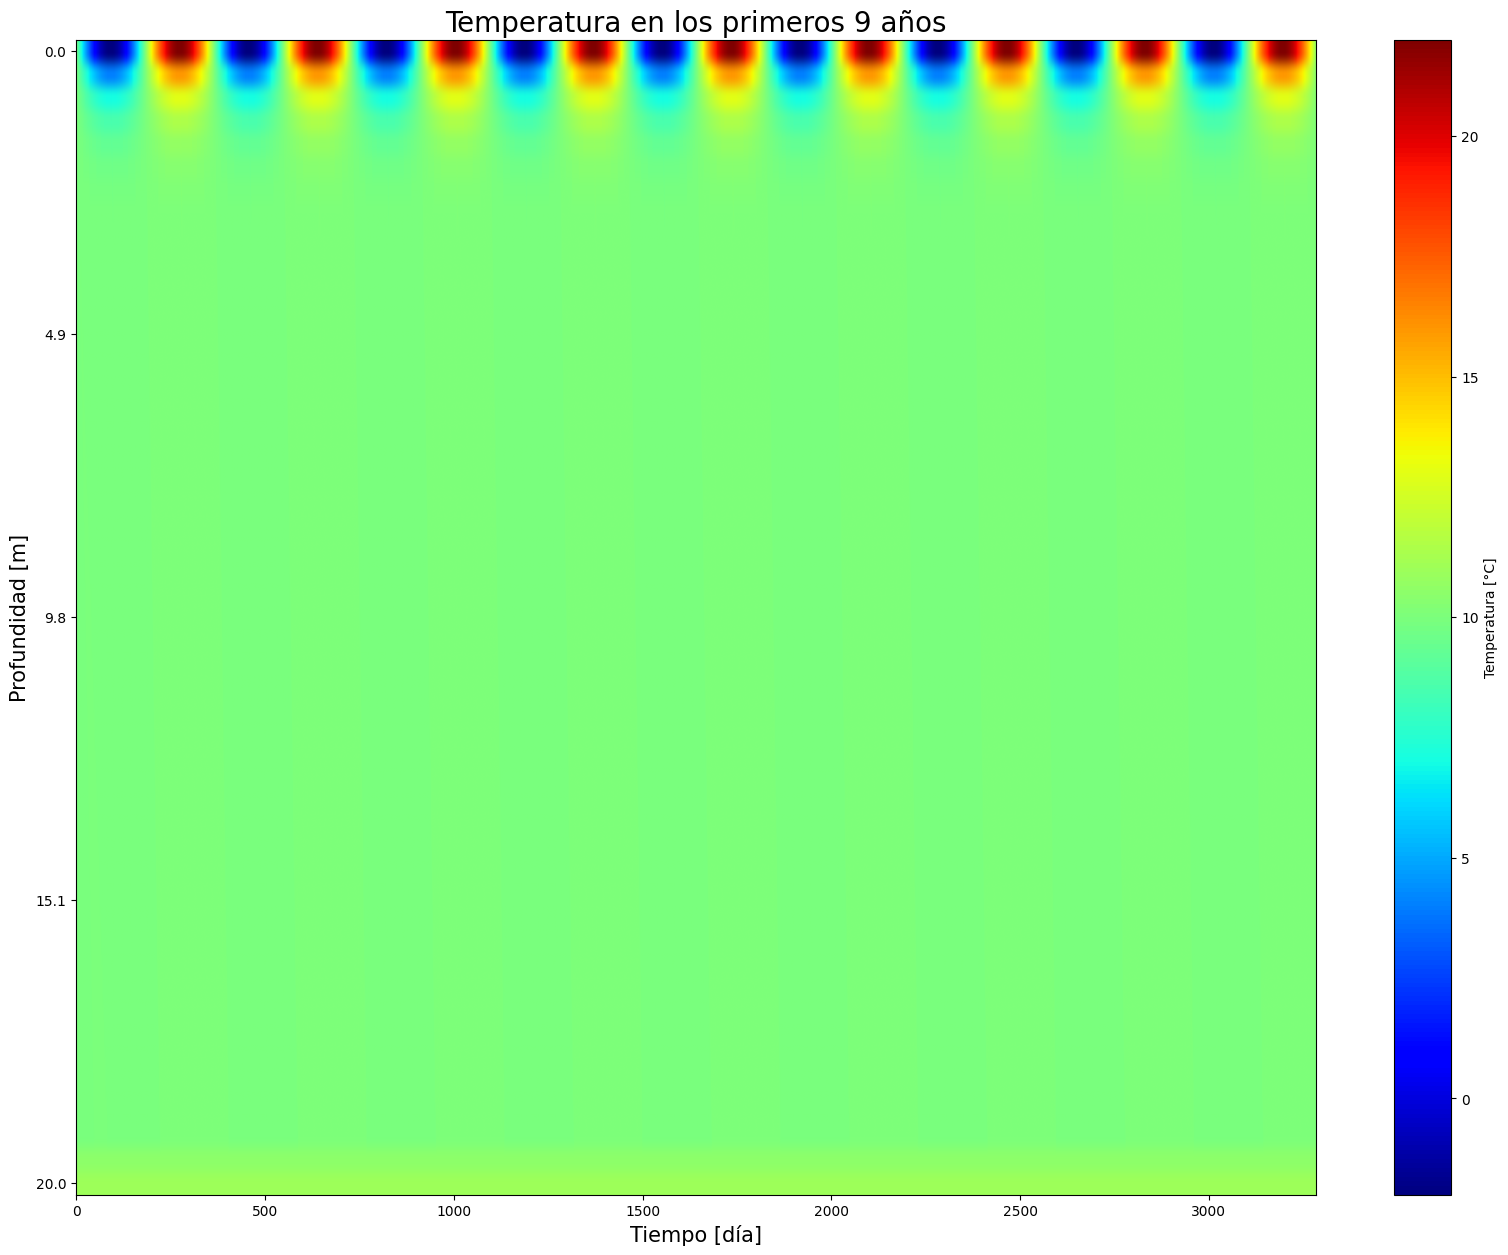

In [39]:
plt.figure(figsize=[20, 15])
plt.title("Temperatura en los primeros 9 años", size = 20)
plt.xlabel("Tiempo [día]", size= 15)
plt.ylabel('Profundidad [m]', size = 15)
plt.yticks([0, (Ny-1)/4, (Ny-1)/2, 3*(Ny-1)/4, Ny-1], [profundo[0], np.round(profundo[int(np.round((Ny-1)/4))],2), np.round(profundo[int(np.round((Ny-1)/2))],2), np.round(profundo[int(np.round(3*(Ny-1)/4))],2) ,np.round(profundo[Ny-1],2)])
plt.imshow(Corteza[:,:3650-365], aspect='auto', cmap='jet')
plt.colorbar(label = 'Temperatura [°C]')


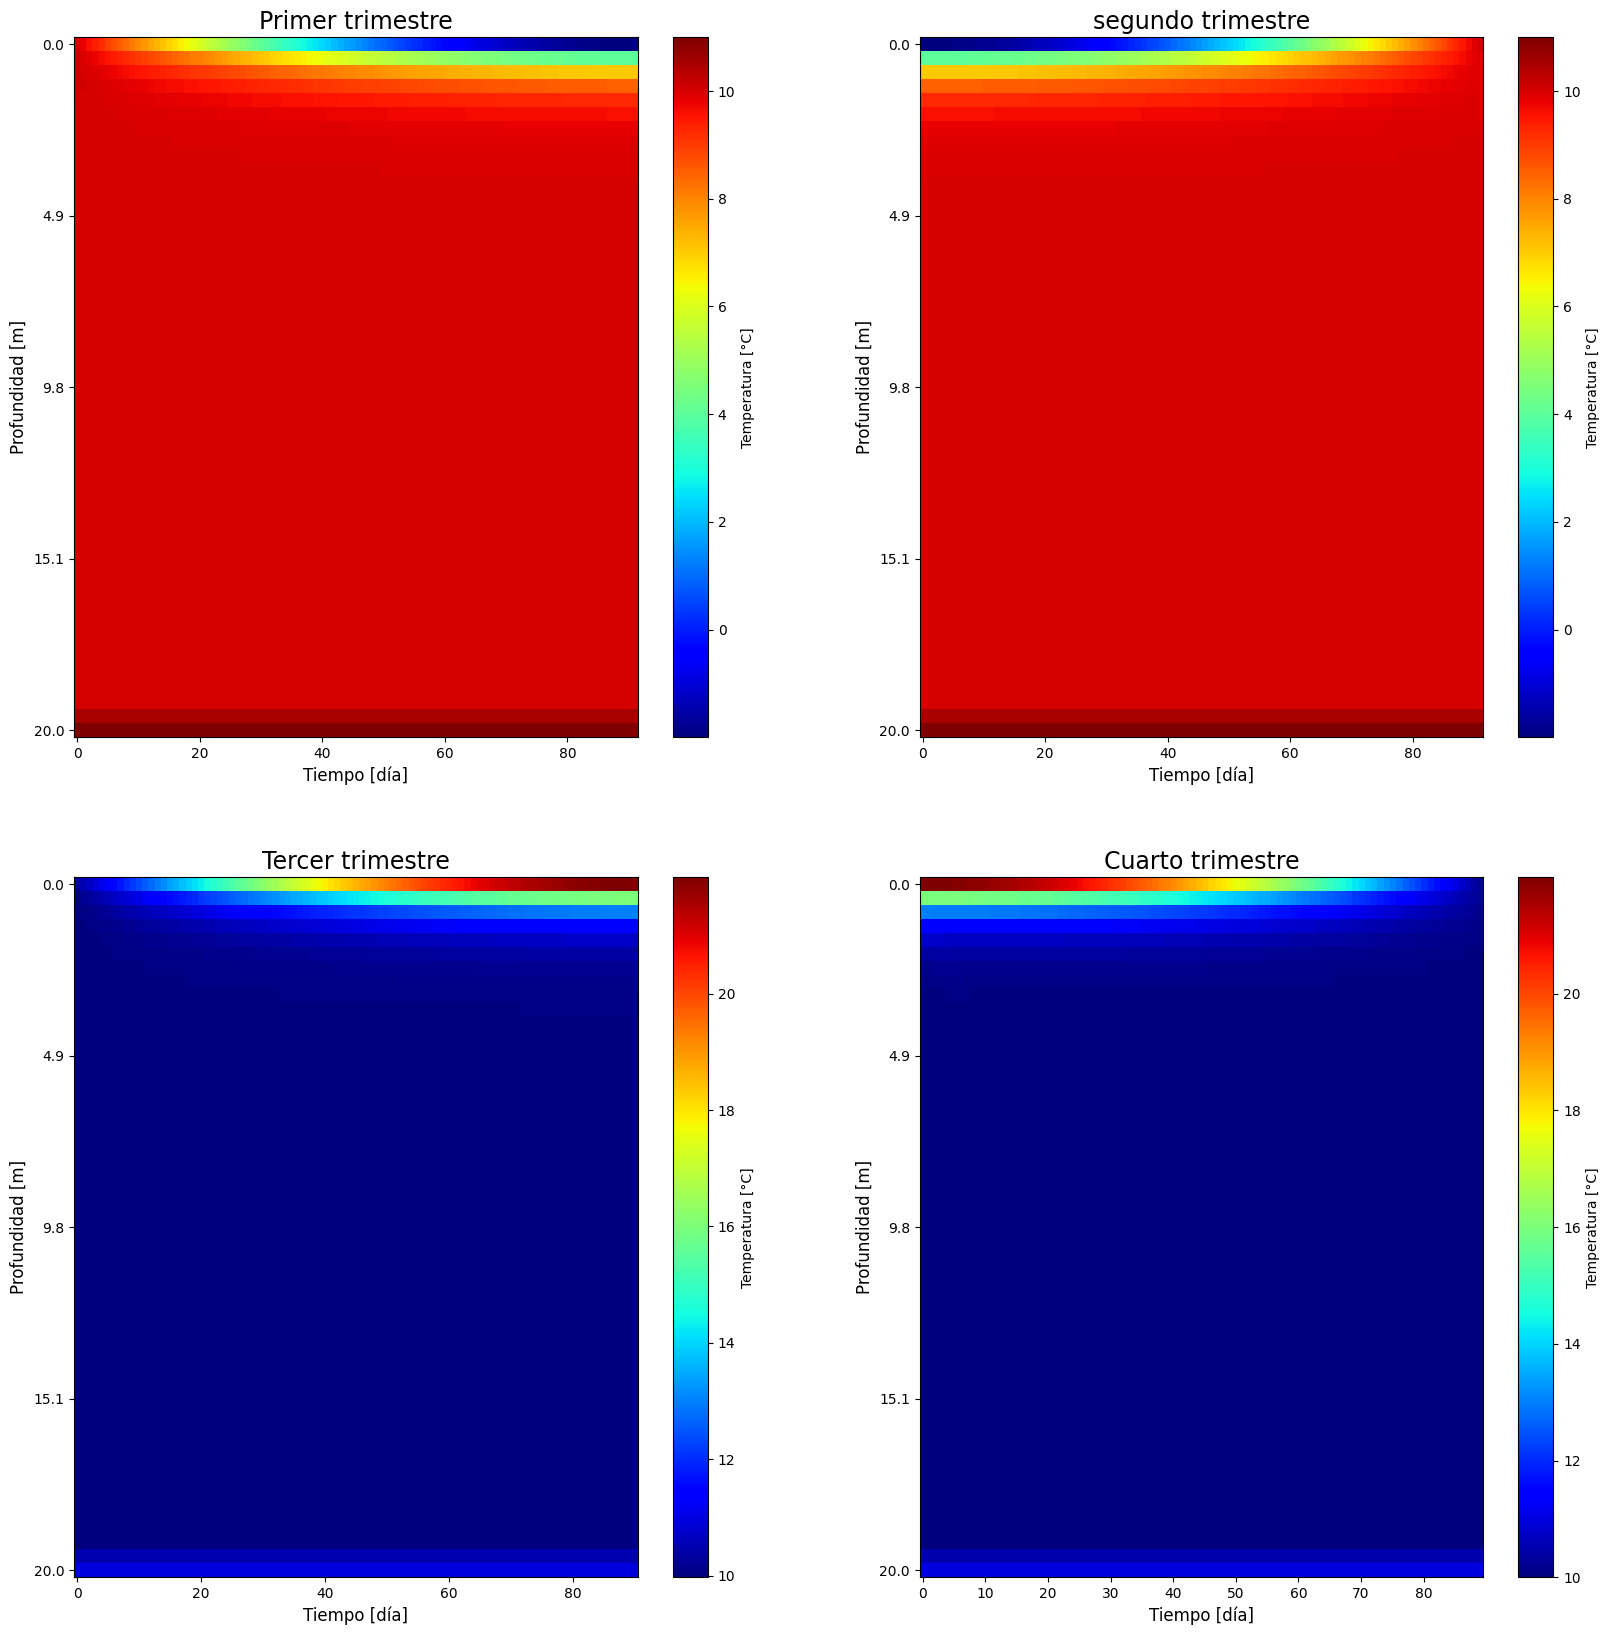

In [41]:
plt.figure(figsize = [20,20])
plt.subplot(2,2,1)
plt.title('Primer trimestre', size = 17)
plt.imshow(Corteza[:,3285: 3377], aspect='auto', cmap ='jet')
plt.xlabel("Tiempo [día]", size= 12)
plt.ylabel('Profundidad [m]', size = 12)
plt.yticks([0, (Ny-1)/4, (Ny-1)/2, 3*(Ny-1)/4, Ny-1], [profundo[0], np.round(profundo[int(np.round((Ny-1)/4))],2), np.round(profundo[int(np.round((Ny-1)/2))],2), np.round(profundo[int(np.round(3*(Ny-1)/4))],2) ,np.round(profundo[Ny-1],2)])
plt.colorbar(label = 'Temperatura [°C]')


plt.subplot(2,2,2)
plt.title('segundo trimestre', size = 17)
plt.imshow(Corteza[:,3377: 3469 ], aspect='auto', cmap ='jet')
plt.xlabel("Tiempo [día]", size= 12)
plt.ylabel('Profundidad [m]', size = 12)
plt.yticks([0, (Ny-1)/4, (Ny-1)/2, 3*(Ny-1)/4, Ny-1], [profundo[0], np.round(profundo[int(np.round((Ny-1)/4))],2), np.round(profundo[int(np.round((Ny-1)/2))],2), np.round(profundo[int(np.round(3*(Ny-1)/4))],2) ,np.round(profundo[Ny-1],2)])
plt.colorbar(label = 'Temperatura [°C]')

plt.subplot(2,2,3)
plt.title('Tercer trimestre', size = 17)
plt.imshow(Corteza[:,3469: 3560], aspect='auto', cmap ='jet')
plt.xlabel("Tiempo [día]", size= 12)
plt.ylabel('Profundidad [m]', size = 12)
plt.yticks([0, (Ny-1)/4, (Ny-1)/2, 3*(Ny-1)/4, Ny-1], [profundo[0], np.round(profundo[int(np.round((Ny-1)/4))],2), np.round(profundo[int(np.round((Ny-1)/2))],2), np.round(profundo[int(np.round(3*(Ny-1)/4))],2) ,np.round(profundo[Ny-1],2)])
plt.colorbar(label = 'Temperatura [°C]')

plt.subplot(2,2,4)
plt.title('Cuarto trimestre', size = 17)
plt.imshow(Corteza[:,3560:], aspect='auto', cmap ='jet')
plt.xlabel("Tiempo [día]", size= 12)
plt.ylabel('Profundidad [m]', size = 12)
plt.yticks([0, (Ny-1)/4, (Ny-1)/2, 3*(Ny-1)/4, Ny-1], [profundo[0], np.round(profundo[int(np.round((Ny-1)/4))],2), np.round(profundo[int(np.round((Ny-1)/2))],2), np.round(profundo[int(np.round(3*(Ny-1)/4))],2) ,np.round(profundo[Ny-1],2)])
plt.colorbar(label = 'Temperatura [°C]')

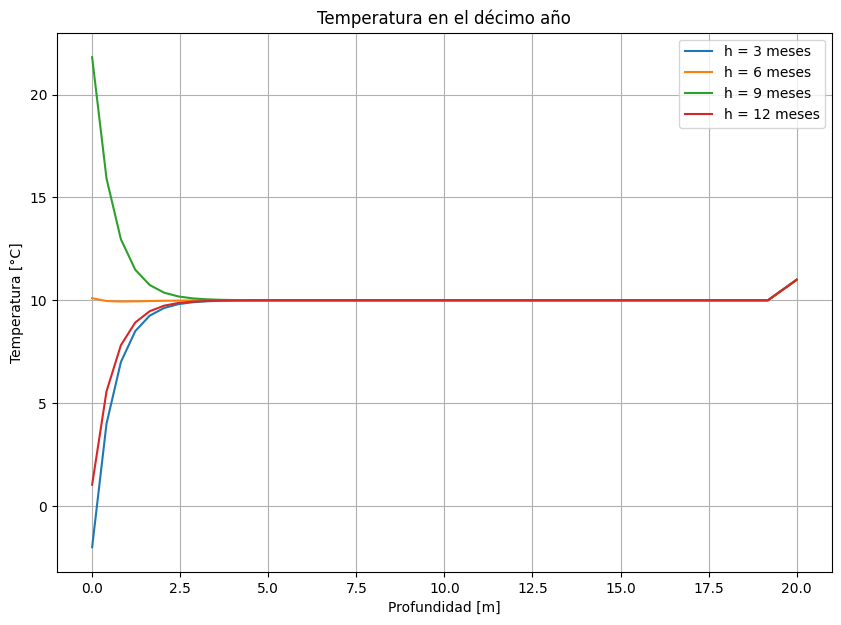

In [396]:
Temp = np.transpose(Corteza)
plt.figure(figsize = [10,7])
plt.title("Temperatura en el décimo año")
plt.plot(profundo, Temp[3376], label = 'h = 3 meses')
plt.plot(profundo, Temp[3468], label = 'h = 6 meses')
plt.plot(profundo, Temp[3569], label = 'h = 9 meses')
plt.plot(profundo, Temp[Ny-1], label = 'h = 12 meses')
plt.xlabel('Profundidad [m]')
plt.ylabel('Temperatura [°C]')
plt.legend()
plt.grid()


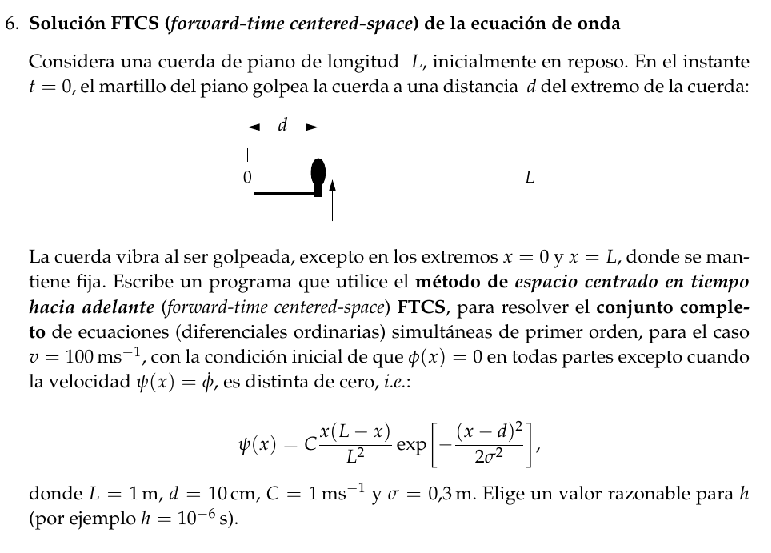

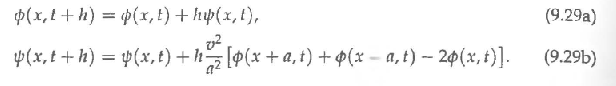

In [6]:
def psi(z): #defino la psi
    L = 1
    d = 0.1
    sigma = 0.3
    psi = z*(L-z)*np.exp(-(z-d)**2/(2*sigma**2))/L**2
    return np.array(psi)
## tiempo inicial es 
t = 0
### tiempo final es 
tf = 1
### los pasos son h = 1e-6
h = 1e-5

### queremos obtener las phi's y las psi's que dependen del tiempo
L = 1
v = 100
cuerda = np.linspace(0,L,100)
a = cuerda[1]-cuerda[0]
Phi_s = [] # Guardaremos las phi'ss y psi's en estas listas para cada instante h
Psi_s = [] 
Phi_0 = np.zeros(np.shape(cuerda)) #los valores iniciales de la phi es que este quita la cuerda, por ello se hace un arreglo en 0
Psi_0 = psi(cuerda) # y los valores iniciales de Psi son los que aplicamos sobre la cuerda
T = [] # para guardar los tiempos que van de h en h
while t < tf:
    Phi_1 = np.copy(Phi_0)#creamos copias para despues comparar
    Psi_1 = np.copy(Psi_0)
    Phi_s.append(Phi_1) #guardamos las copias 
    Psi_s.append(Psi_1)
    for i in range (len(cuerda)):
        if i==0 or i== (len(cuerda)-1):
            Phi_0[i] = 0 #los extremos de la cuerda se quedan en 0, dado que son fijas
            Psi_0[i] = 0
            
        else: # las demás se mueven acorde a las ecuaciones de arriba.
            Phi_0[i] = Phi_0[i] + h*Psi_0[i]
            Psi_0[i] = Psi_0[i] + (h*(v/a)**2)*(Phi_0[i+1] + Phi_0[i-1] -2*Phi_0[i])
    T.append(t)
    t += h
       

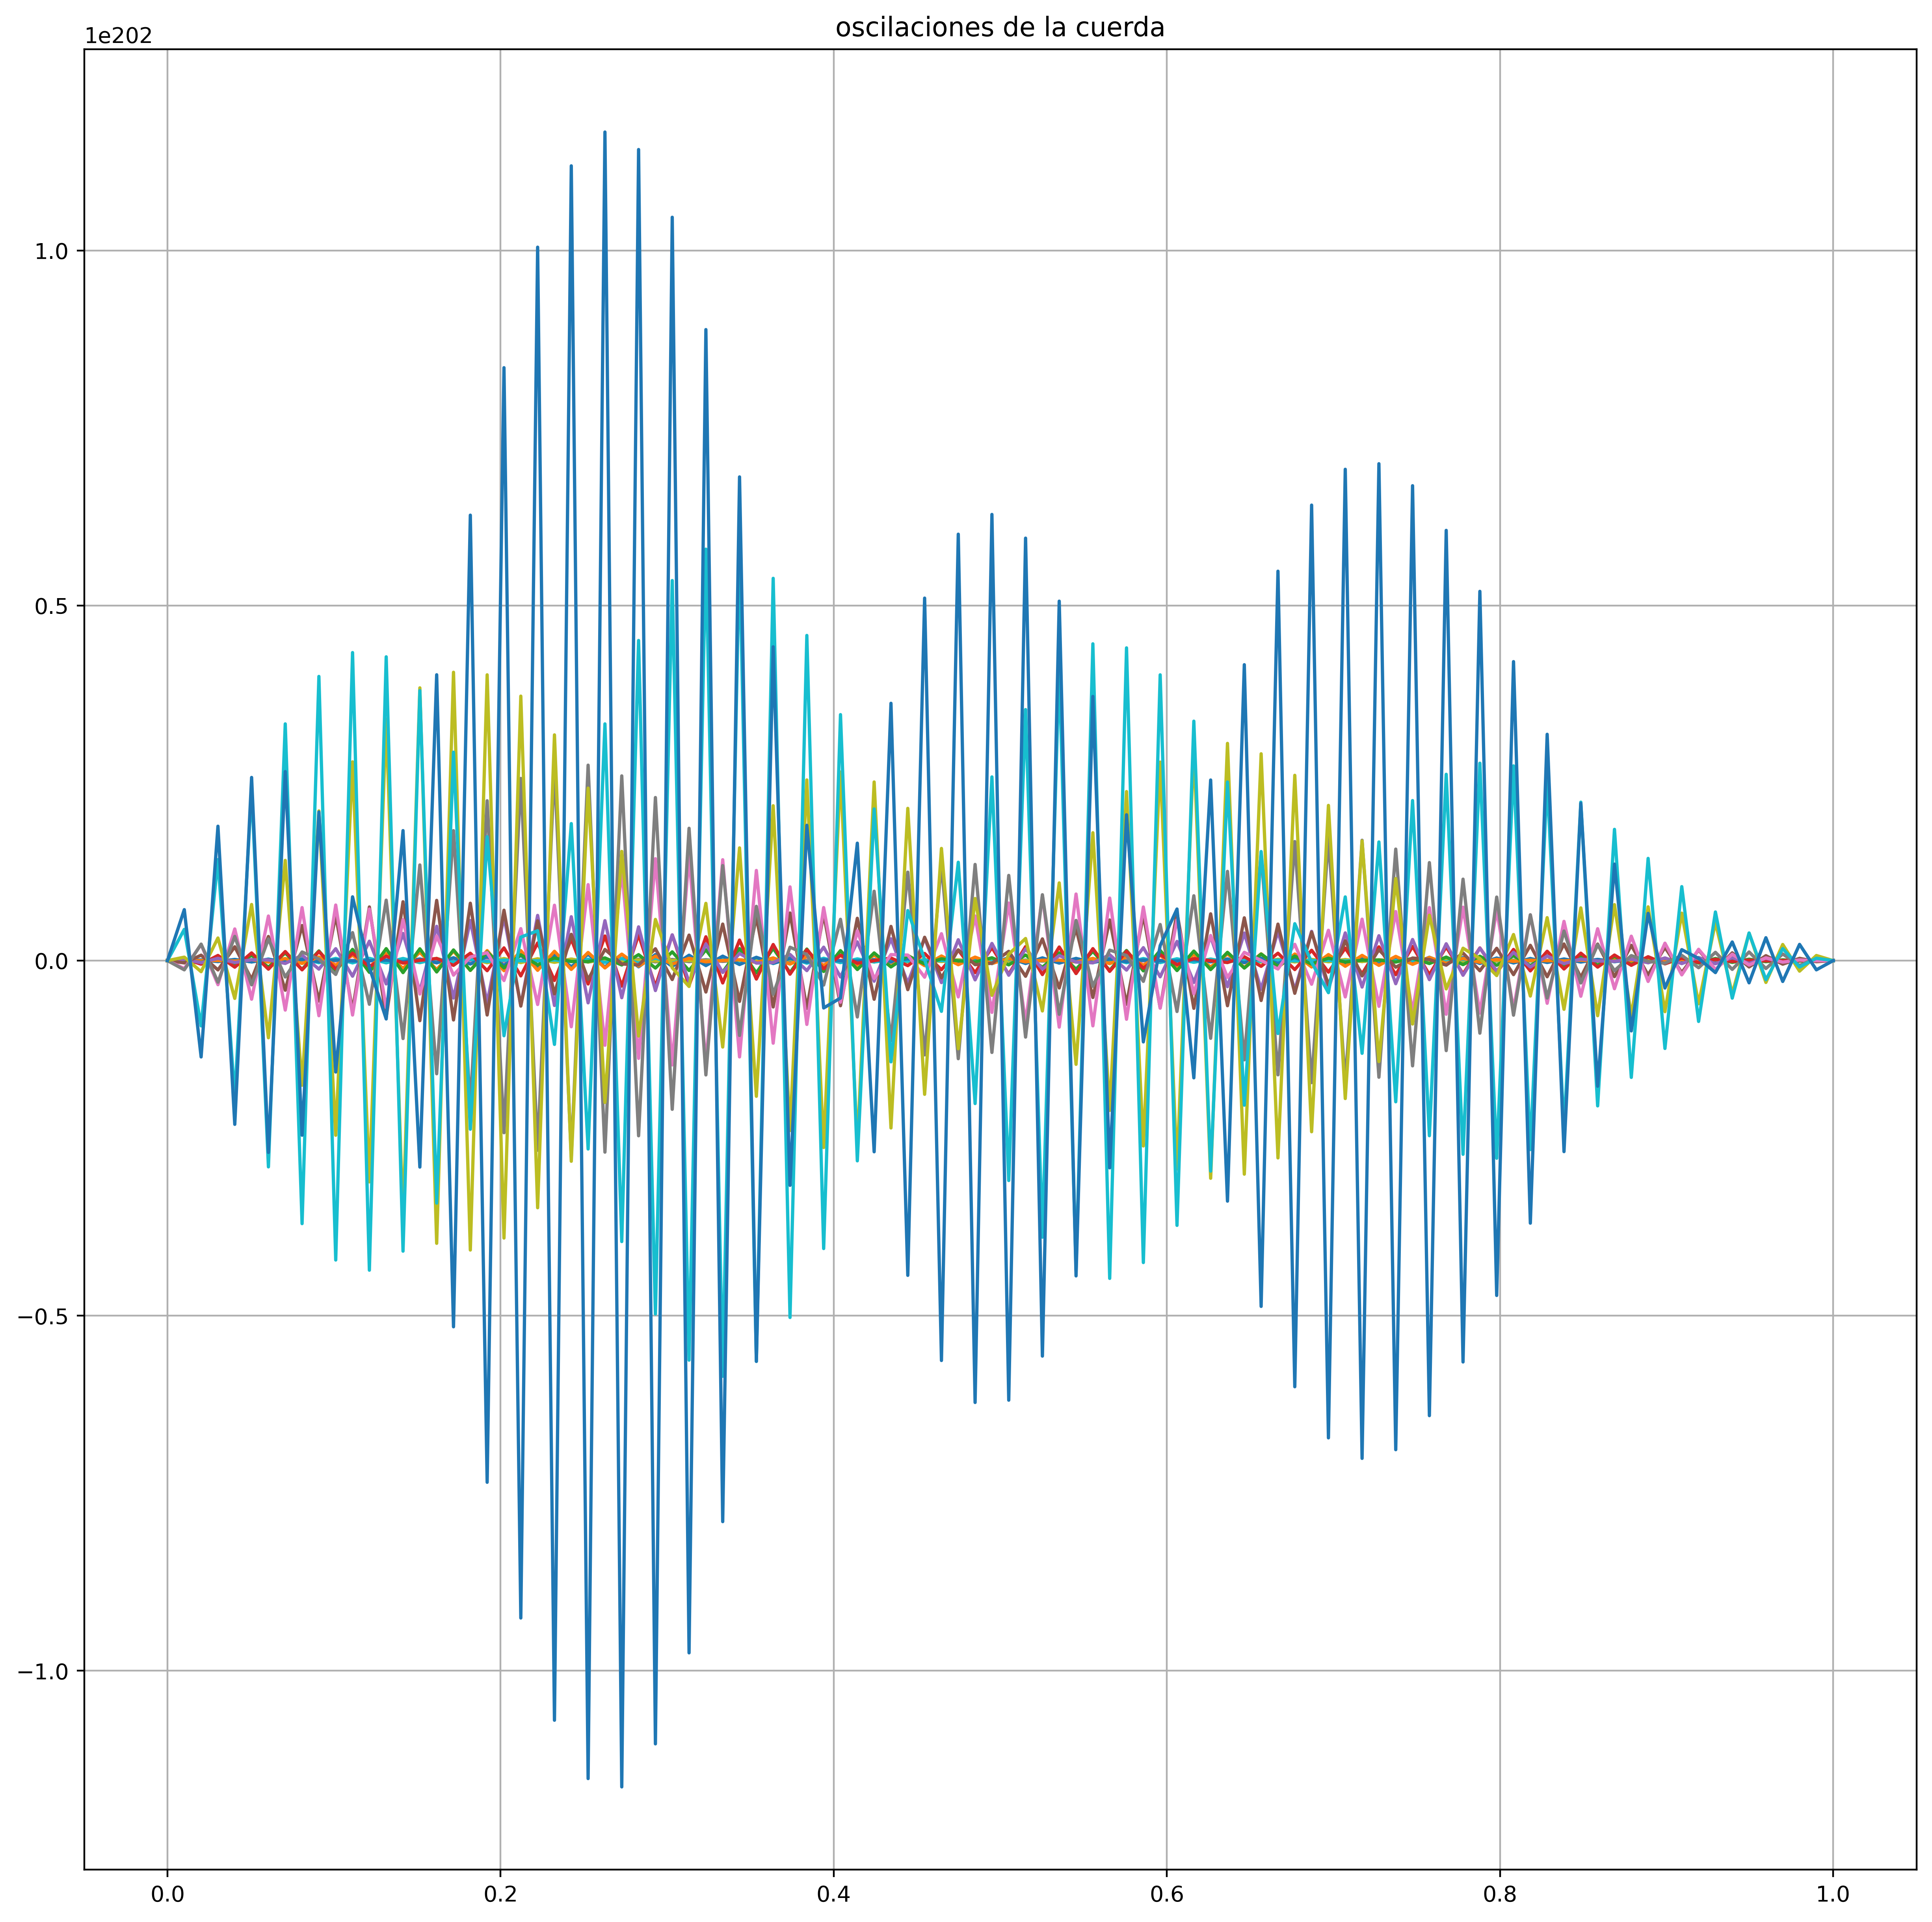

In [25]:
fig, ax = plt.subplots(figsize = (15,15), dpi = 400)
for i in range(0,len(T),100):
    ax.plot(cuerda, Phi_s[i])
plt.title('oscilaciones de la cuerda')
ax.grid()